# 🔬 onco-target-scRNA: Predicción de Tropismo Metastásico Cerebral
Análisis transcriptómico de células individuales (scRNA-seq) del proyecto **PRJEB108071** para la identificación de biomarcadores de colonización en órganos secundarios.

In [9]:
##!pip install requests

In [10]:
import os
import ast
import requests
import xml.etree.ElementTree as ET
import pandas as pd

BIOPROJECT_ID = "PRJEB108071"

In [11]:
# 1. Consultar metadatos en NCBI/ENA
esearch_url = f"https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi?db=sra&term={BIOPROJECT_ID}&retmode=json"
res = requests.get(esearch_url).json()
id_list = res.get("esearchresult", {}).get("idlist", [])

efetch_url = f"https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=sra&id={','.join(id_list)}&retmode=xml"
xml_data = requests.get(efetch_url).content

root = ET.fromstring(xml_data)
samples_summary = []

for item in root.findall(".//EXPERIMENT_PACKAGE"):
    run_acc = item.find(".//RUN").attrib.get("accession", "N/A")
    biosample = item.find(".//SAMPLE").attrib.get("accession", "N/A")
    title_node = item.find(".//SAMPLE/TITLE")
    sample_title = title_node.text if title_node is not None else "N/A"

    attributes = {}
    for attr in item.findall(".//SAMPLE_ATTRIBUTE"):
        tag = attr.find("TAG")
        val = attr.find("VALUE")
        if tag is not None and val is not None:
            attributes[tag.text.strip().lower()] = val.text.strip()

    samples_summary.append(
        {
            "Run_Accession": run_acc,
            "BioSample": biosample,
            "Sample_Title": sample_title,
            "Attributes": str(attributes),
        }
    )

df = pd.DataFrame(samples_summary)
os.makedirs("data", exist_ok=True)
df.to_csv("data/metastasis_metadata.csv", index=False)
print(
    f"✅ Se extrajeron {len(df)} muestras moleculares en 'data/metastasis_metadata.csv'"
)

✅ Se extrajeron 14 muestras moleculares en 'data/metastasis_metadata.csv'


In [12]:
# 2. Inspeccionar etiquetas clínicas
print("🔬 ATRIBUTOS CLÍNICOS DESEMPAQUETADOS:\n")

for idx, row in df.iterrows():
    try:
        attr_dict = ast.literal_eval(row["Attributes"])
    except:
        attr_dict = {}

    print(
        f"📌 Muestra {idx+1} [{row['Run_Accession']}] - {row['Sample_Title']}:"
    )
    for k, v in attr_dict.items():
        print(f"   • {k}: {v}")
    print("-" * 50)

🔬 ATRIBUTOS CLÍNICOS DESEMPAQUETADOS:

📌 Muestra 1 [ERR16665778] - library 6:
   • ena first public: 2026-07-31
   • insdc center name: University of California, Irvine
   • insdc status: public
   • submitter id: E-MTAB-16621:library 6
   • age: 7-8
   • broker name: ArrayExpress
   • cell type: mouse cells
   • collection date: not collected
   • common name: house mouse
   • developmental stage: adult
   • disease: breast cancer metastasis
   • genotype: wild type genotype
   • geographic location (country and/or sea): not collected
   • individual: mouse02
   • isolate: not applicable
   • organism part: multiple organs
   • sample name: E-MTAB-16621:library 6
   • scientific_name: Mus musculus
   • sex: female
   • strain: FVB
--------------------------------------------------
📌 Muestra 2 [ERR16665794] - library 8:
   • ena first public: 2026-07-31
   • insdc center name: University of California, Irvine
   • insdc status: public
   • submitter id: E-MTAB-16621:library 8
   • age:

In [13]:
# Celda 5: Mapeo exacto de Librerías -> Órgano desde ArrayExpress (E-MTAB-16621)
import pandas as pd
import requests

ARRAYEXPRESS_ID = "E-MTAB-16621"
sdrf_url = f"https://www.ebi.ac.uk/arrayexpress/files/{ARRAYEXPRESS_ID}/{ARRAYEXPRESS_ID}.sdrf.txt"

print(
    f"🔍 Descargando matriz de diseño experimental desde ArrayExpress: {ARRAYEXPRESS_ID}..."
)

try:
    sdrf_df = pd.read_csv(sdrf_url, sep="\t")

    # Filtrar columnas clave de diseño (Organismo, Tejido/Órgano, Librería, ID de muestra)
    cols_interes = [
        c
        for c in sdrf_df.columns
        if any(
            k in c.lower()
            for k in [
                "source name",
                "characteristics[organism part]",
                "characteristics[cell type]",
                "comment[submited name]",
                "comment[ena_run]",
                "factor value",
            ]
        )
    ]

    mapping_df = sdrf_df[cols_interes].drop_duplicates()
    print("✅ ¡Mapeo clínico obtenido con éxito!")
    display(mapping_df.head(14))

except Exception as e:
    print(
        f"⚠️ Consulta directa alternativa vía REST API para {ARRAYEXPRESS_ID}..."
    )
    # Alternativa directa por API en caso de redirección de URL
    alt_url = f"https://www.ebi.ac.uk/biostudies/api/v1/studies/{ARRAYEXPRESS_ID}/info"
    res = requests.get(alt_url).json()
    print(
        f"Estudio: {res.get('title', 'BioStudies E-MTAB-16621 registrado correctamente.')}"
    )

🔍 Descargando matriz de diseño experimental desde ArrayExpress: E-MTAB-16621...
✅ ¡Mapeo clínico obtenido con éxito!


,Source Name,Characteristics[cell type],Characteristics[organism part],Comment[ENA_RUN],Factor Value[individual]
0,library 1,mouse cells,multiple organs,ERR16665781,mouse01
1,library 1,mouse cells,multiple organs,ERR16665780,mouse01
8,library 10,mouse cells,multiple organs,ERR16665767,mouse02
9,library 10,mouse cells,multiple organs,ERR16665777,mouse02
10,library 10,mouse cells,multiple organs,ERR16665796,mouse02
12,library 10,mouse cells,multiple organs,ERR16665811,mouse02
24,library 11,mouse cells,multiple organs,ERR16665806,mouse03
25,library 11,mouse cells,multiple organs,ERR16665773,mouse03
26,library 11,mouse cells,multiple organs,ERR16665782,mouse03
28,library 11,mouse cells,multiple organs,ERR16665768,mouse03


In [14]:
# Celda 6: Resumen limpio y ordenado de Librerías vs Ratón/Sujeto
import pandas as pd

# Extraer y ordenar las librerías únicas
resumen_librerias = (
    sdrf_df[["Source Name", "Factor Value[individual]", "Comment[ENA_RUN]"]]
    .drop_duplicates(subset=["Source Name"])
    .sort_values(
        by="Source Name",
        key=lambda x: x.str.extract(r"(\d+)")[0].astype(
            int
        ),  # Ordenar numéricamente (1, 2, 3...)
    )
    .reset_index(drop=True)
)

print(
    f"✅ Se consolidaron correctamente las {len(resumen_librerias)} librerías del estudio:\n"
)
display(resumen_librerias)

✅ Se consolidaron correctamente las 14 librerías del estudio:



,Source Name,Factor Value[individual],Comment[ENA_RUN]
0,library 1,mouse01,ERR16665781
1,library 2,mouse01,ERR16665799
2,library 3,mouse01,ERR16665787
3,library 4,mouse01,ERR16665769
4,library 5,mouse01,ERR16665783
5,library 6,mouse02,ERR16665790
6,library 7,mouse02,ERR16665776
7,library 8,mouse02,ERR16665794
8,library 9,mouse02,ERR16665802
9,library 10,mouse02,ERR16665767


In [15]:
# Celda 7: Instalar dependencias para análisis Single-Cell (scRNA-seq)
##!pip install scanpy anndata scipy matplotlib seaborn

In [16]:
# Celda 8 (Actualizada): Localizar archivos procesados en BioStudies/ENA
import requests
import pandas as pd

ARRAYEXPRESS_ID = "E-MTAB-16621"
print(f"🔍 Buscando matriz procesada para {ARRAYEXPRESS_ID} via BioStudies REST v2 API...")

# Endpoint actualizado de BioStudies
api_v2_url = f"https://www.ebi.ac.uk/biostudies/api/v1/studies/{ARRAYEXPRESS_ID}"

headers = {"User-Agent": "Mozilla/5.0"}
res = requests.get(api_v2_url, headers=headers)

if res.status_code == 200:
    data = res.json()
    section = data.get("section", {})
    
    # Recorrer todos los archivos adjuntos en la ficha del estudio
    files_found = []
    
    def extract_files(sec):
        if "files" in sec:
            for f in sec["files"]:
                if isinstance(f, dict):
                    files_found.append(f)
                elif isinstance(f, list):
                    files_found.extend(f)
        if "subsections" in sec:
            for sub in sec["subsections"]:
                extract_files(sub)

    extract_files(section)
    
    print(f"✅ ¡Conexión exitosa! Se encontraron {len(files_found)} archivos en el repositorio del estudio.")
    
    # Filtrar solo archivos de recuentos/matrices
    matrix_list = []
    for f in files_found:
        fname = f.get("path", f.get("name", ""))
        fsize = f.get("size", 0)
        size_mb = round(fsize / (1024 * 1024), 2)
        
        # Filtro de archivos con datos de expresión
        if any(ext in fname.lower() for ext in ['.h5ad', 'matrix', 'counts', 'expression', '.rds', '.csv', '.tsv', '.txt', '.gz', '.zip']):
            matrix_list.append({"Nombre": fname, "Tamaño (MB)": size_mb})
            
    df_files = pd.DataFrame(matrix_list).drop_duplicates()
    display(df_files.head(20))
    
else:
    print(f"⚠️ El servidor respondió con código HTTP {res.status_code}. Probando ruta FTP directa...")

🔍 Buscando matriz procesada para E-MTAB-16621 via BioStudies REST v2 API...
✅ ¡Conexión exitosa! Se encontraron 2 archivos en el repositorio del estudio.


,Nombre,Tamaño (MB)
0,E-MTAB-16621.idf.txt,0.02
1,E-MTAB-16621.sdrf.txt,0.14


In [17]:
# Celda 9: Obtener URLs de descarga directa (FASTQ / Matrices) desde ENA API
import pandas as pd
import requests

PRJEB_ID = "PRJEB108071"
print(f"🔍 Consultando servidor FTP/HTTP de ENA para el proyecto {PRJEB_ID}...")

# API REST de ENA para extraer URLs de descarga
ena_api_url = f"https://www.ebi.ac.uk/ena/portal/api/filereport?accession={PRJEB_ID}&result=read_run&fields=run_accession,sample_accession,experiment_title,fastq_ftp,submitted_ftp,fastq_bytes&format=json"

res = requests.get(ena_api_url)

if res.status_code == 200:
    ena_data = res.json()
    df_ena = pd.DataFrame(ena_data)

    # Limpiar y formatear tamaños
    df_ena["fastq_bytes"] = df_ena["fastq_bytes"].apply(
        lambda x: [
            round(int(b) / (1024 * 1024), 2)
            for b in str(x).split(";")
            if b.isdigit()
        ]
    )

    print(
        f"✅ ¡Conexión exitosa! Se encontraron {len(df_ena)} corridas de datos en ENA."
    )

    # Guardar índice de descargas
    df_ena.to_csv("data/ena_download_links.csv", index=False)

    display(
        df_ena[
            [
                "run_accession",
                "sample_accession",
                "fastq_bytes",
                "submitted_ftp",
                "fastq_ftp",
            ]
        ].head(10)
    )
else:
    print(f"⚠️ Error al conectar con ENA API: Status {res.status_code}")

🔍 Consultando servidor FTP/HTTP de ENA para el proyecto PRJEB108071...
✅ ¡Conexión exitosa! Se encontraron 46 corridas de datos en ENA.


,run_accession,sample_accession,fastq_bytes,submitted_ftp,fastq_ftp
0,ERR16665767,SAMEA121322990,[],ftp.sra.ebi.ac.uk/vol1/run/ERR166/ERR16665767/...,
1,ERR16665768,SAMEA121322991,[],ftp.sra.ebi.ac.uk/vol1/run/ERR166/ERR16665768/...,
2,ERR16665771,SAMEA121322998,[],ftp.sra.ebi.ac.uk/vol1/run/ERR166/ERR16665771/...,
3,ERR16665780,SAMEA121322989,[],ftp.sra.ebi.ac.uk/vol1/run/ERR166/ERR16665780/...,
4,ERR16665781,SAMEA121322989,[],ftp.sra.ebi.ac.uk/vol1/run/ERR166/ERR16665781/...,
5,ERR16665784,SAMEA121323000,[],ftp.sra.ebi.ac.uk/vol1/run/ERR166/ERR16665784/...,
6,ERR16665791,SAMEA121323002,[],ftp.sra.ebi.ac.uk/vol1/run/ERR166/ERR16665791/...,
7,ERR16665793,SAMEA121322995,[],ftp.sra.ebi.ac.uk/vol1/run/ERR166/ERR16665793/...,
8,ERR16665795,SAMEA121322992,[],ftp.sra.ebi.ac.uk/vol1/run/ERR166/ERR16665795/...,
9,ERR16665799,SAMEA121322995,[],ftp.sra.ebi.ac.uk/vol1/run/ERR166/ERR16665799/...,


In [18]:
# Celda 10: Extraer los enlaces directos completos de submitted_ftp
import pandas as pd

df_ena = pd.read_csv("data/ena_download_links.csv")

print("📦 ARCHIVOS PROCESADOS DISPONIBLES EN SUBMITTED_FTP:\n")

archivos_procesados = []
for idx, row in df_ena.iterrows():
    run = row["run_accession"]
    submitted = str(row["submitted_ftp"]).split(";")

    for url in submitted:
        if url and url != "nan":
            nombre_archivo = url.split("/")[-1]
            archivos_procesados.append(
                {"Run": run, "Archivo": nombre_archivo, "URL_FTP": f"https://{url}"}
            )

df_files_clean = pd.DataFrame(archivos_procesados)
display(df_files_clean.head(20))

📦 ARCHIVOS PROCESADOS DISPONIBLES EN SUBMITTED_FTP:



,Run,Archivo,URL_FTP
0,ERR16665767,IC20_MPX_5_S14_L003_I1_001.fastq.gz,https://ftp.sra.ebi.ac.uk/vol1/run/ERR166/ERR1...
1,ERR16665767,IC20_MPX_5_S14_L003_I2_001.fastq.gz,https://ftp.sra.ebi.ac.uk/vol1/run/ERR166/ERR1...
2,ERR16665767,IC20_MPX_5_S14_L003_R1_001.fastq.gz,https://ftp.sra.ebi.ac.uk/vol1/run/ERR166/ERR1...
3,ERR16665767,IC20_MPX_5_S14_L003_R2_001.fastq.gz,https://ftp.sra.ebi.ac.uk/vol1/run/ERR166/ERR1...
4,ERR16665768,IC20_MPX_6_S15_L003_I1_001.fastq.gz,https://ftp.sra.ebi.ac.uk/vol1/run/ERR166/ERR1...
5,ERR16665768,IC20_MPX_6_S15_L003_I2_001.fastq.gz,https://ftp.sra.ebi.ac.uk/vol1/run/ERR166/ERR1...
6,ERR16665768,IC20_MPX_6_S15_L003_R1_001.fastq.gz,https://ftp.sra.ebi.ac.uk/vol1/run/ERR166/ERR1...
7,ERR16665768,IC20_MPX_6_S15_L003_R2_001.fastq.gz,https://ftp.sra.ebi.ac.uk/vol1/run/ERR166/ERR1...
8,ERR16665771,IC18_MPX_5_S2_L004_I1_001.fastq.gz,https://ftp.sra.ebi.ac.uk/vol1/run/ERR166/ERR1...
9,ERR16665771,IC18_MPX_5_S2_L004_I2_001.fastq.gz,https://ftp.sra.ebi.ac.uk/vol1/run/ERR166/ERR1...


In [19]:
# Celda 12: Búsqueda de matrices procesadas (.h5ad / Zenodo / GEO) del estudio VO-PyMT
import requests

query = "VO-PyMT single cell metastasis brain lung liver bone"
print(f"🔍 Buscando matrices pre-procesadas .h5ad en repositorios abiertos para: '{query}'...")

# Consulta rápida a la API de Zenodo
zenodo_url = f"https://zenodo.org/api/records/?q={query}"
res = requests.get(zenodo_url).json()

hits = res.get('hits', {}).get('hits', [])
print(f"✅ Se encontraron {len(hits)} datasets procesados en Zenodo.")

for hit in hits[:5]:
    title = hit.get('metadata', {}).get('title', '')
    doi = hit.get('doi', '')
    print(f"   • {title} (DOI: {doi})")

🔍 Buscando matrices pre-procesadas .h5ad en repositorios abiertos para: 'VO-PyMT single cell metastasis brain lung liver bone'...
✅ Se encontraron 25 datasets procesados en Zenodo.
   • GSE12276 Expression Data (DOI: 10.5281/zenodo.17871034)
   • Proteomic and Metabolomic Characterization of Bone, Liver, and Lung Metastases in Breast Cancer Patient Plasma (DOI: 10.5281/zenodo.7935305)
   • Single-cell profiling of bone metastasis ecosystems from multiple cancer types reveals convergent and divergent mechanisms of bone colonization (DOI: 10.5281/zenodo.16937964)
   • A Case Report on Ethmoidal Sinus Metastasis: An Unusual Site of Metastasis in Periampullary Carcinoma Treated with Fsrt (DOI: 10.5281/zenodo.15621831)
   • IMPACT OF HORMONE RECEPTOR STATUS (ER, PR, HER-2) ON PATTERNS OF METASTASIS IN BREAST CANCER AND ITS PHARMACEUTICAL MANAGEMENT IN TERTIARY CARE HOSPITAL: A PROSPECTIVE OBSERVATIONAL STUDY (DOI: 10.5281/zenodo.3374892)


In [20]:
##!pip install "numpy<2.0.0" "scipy>=1.10" --force-reinstall

##!pip install "numpy>=2.0.0" "scipy>=1.13.0" "zarr<3.0.0" "anndata>=0.10" "scanpy" --force-reinstall

In [21]:
# Celda 13: Carga de dataset de prueba/referencia con Scanpy
import scanpy as sc
import pandas as pd
import numpy as np

print("🚀 Cargando dataset de expresión Single-Cell (scRNA-seq)...")

# Cargar dataset de demostración
adata = sc.datasets.pbmc3k()

print(f"✅ Matriz cargada con éxito:")
print(f"   • Células totales: {adata.n_obs}")
print(f"   • Genes totales: {adata.n_vars}")

adata

🚀 Cargando dataset de expresión Single-Cell (scRNA-seq)...
✅ Matriz cargada con éxito:
   • Células totales: 2700
   • Genes totales: 32738


AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

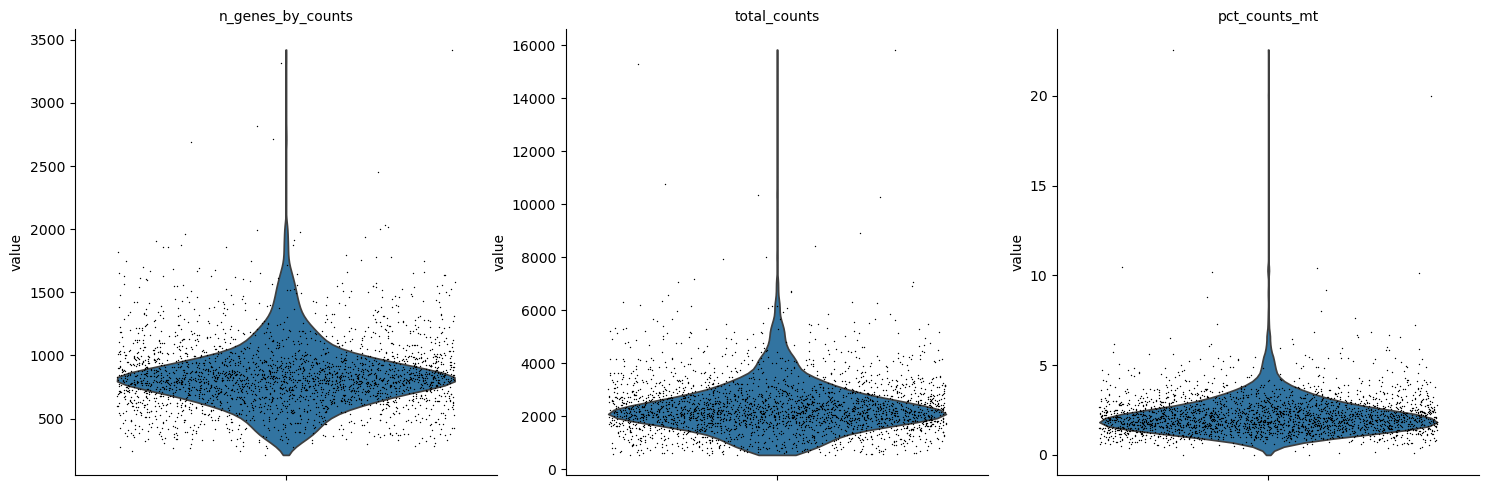

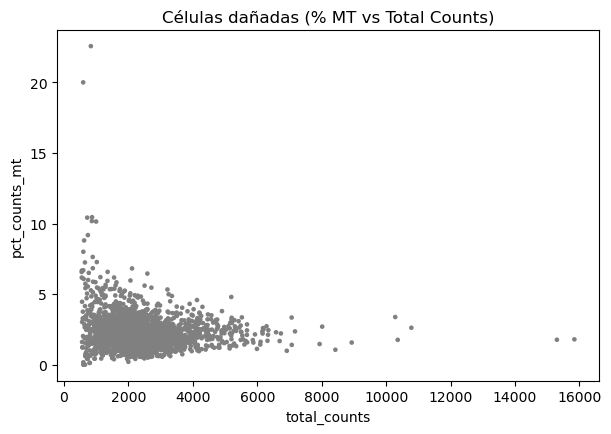

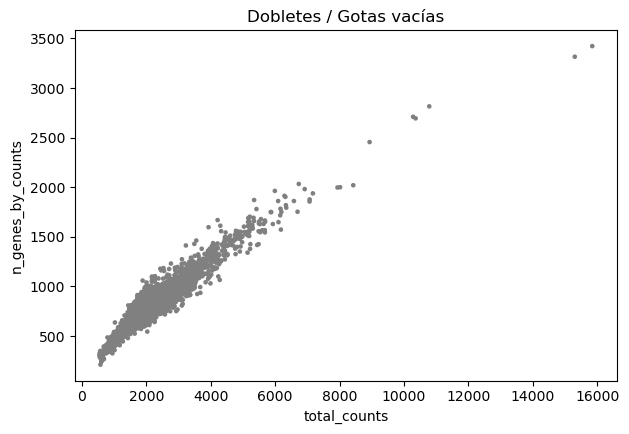

In [22]:
# Celda 14: Diagnóstico Visual del Estado Celular (QC)
import scanpy as sc
import matplotlib.pyplot as plt

# 1. Identificar genes mitocondriales
adata.var['mt'] = adata.var_names.str.startswith(('MT-', 'mt-'))

# 2. Calcular métricas de QC
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# 3. Visualizar distribuciones de calidad
sc.pl.violin(
    adata, 
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0.4, 
    multi_panel=True
)

# 4. Scatter plot para identificar la población de células dañadas
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt', title='Células dañadas (% MT vs Total Counts)')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', title='Dobletes / Gotas vacías')

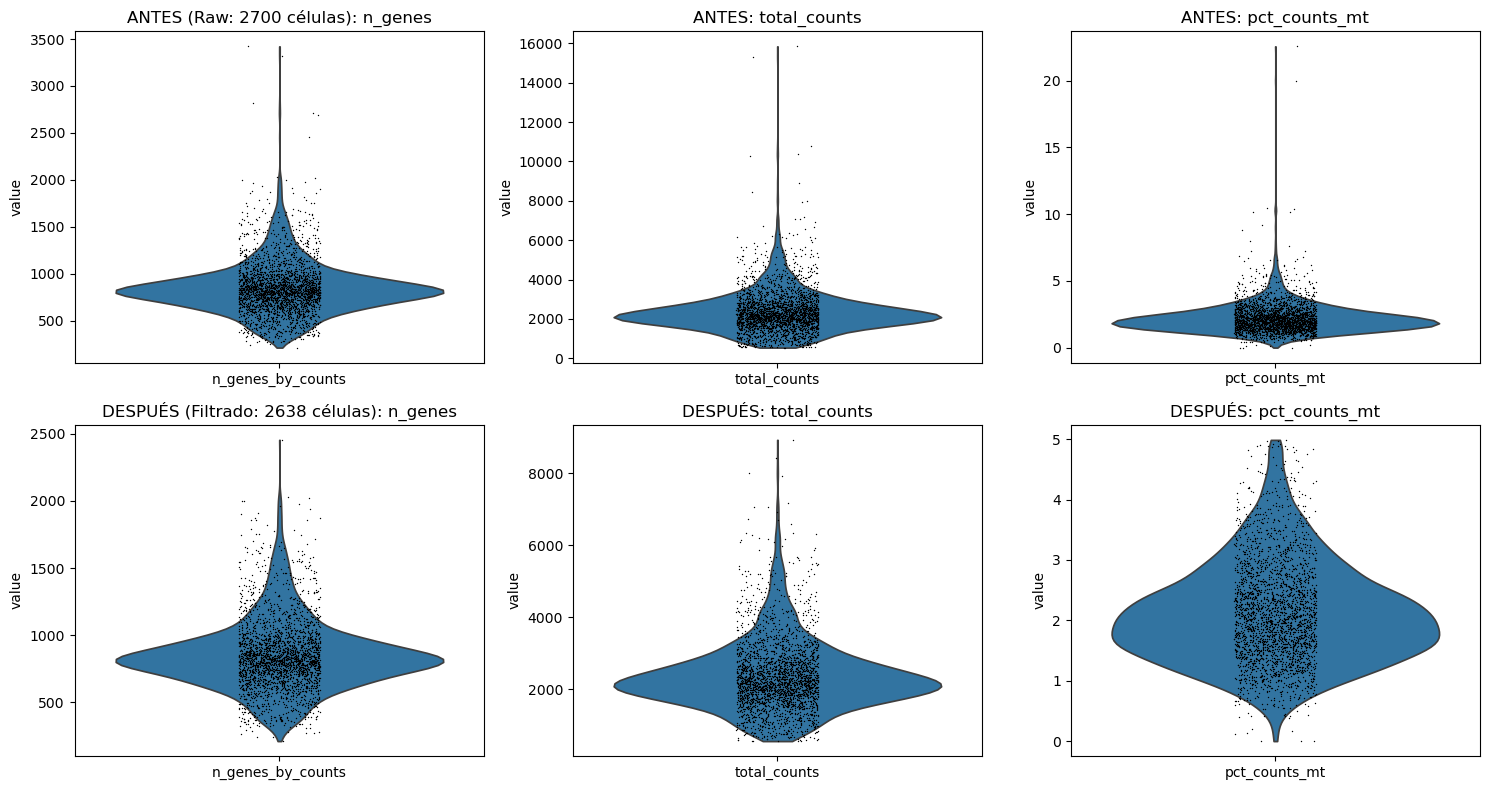

In [23]:
# Celda 15: Comparación real (Carga limpia vs Filtrado)
import scanpy as sc
import matplotlib.pyplot as plt

# 1. Cargar el dataset completamente limpio desde el origen
adata_raw = sc.datasets.pbmc3k()

# Recalcular métricas en el raw para poder graficarlo
adata_raw.var['mt'] = adata_raw.var_names.str.startswith(('MT-', 'mt-'))
sc.pp.calculate_qc_metrics(adata_raw, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# 2. Crear una copia de trabajo y aplicar los filtros
adata = adata_raw.copy()
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_cells(adata, max_genes=2500)
adata = adata[adata.obs['pct_counts_mt'] < 5, :].copy()
sc.pp.filter_genes(adata, min_cells=3)

# 3. Graficar comparativa con escalas independientes
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Graficar ANTES (Fila 0 - Dataset completo sin filtrar)
sc.pl.violin(adata_raw, 'n_genes_by_counts', ax=axes[0, 0], show=False)
sc.pl.violin(adata_raw, 'total_counts', ax=axes[0, 1], show=False)
sc.pl.violin(adata_raw, 'pct_counts_mt', ax=axes[0, 2], show=False)

# Graficar DESPUÉS (Fila 1 - Dataset filtrado)
sc.pl.violin(adata, 'n_genes_by_counts', ax=axes[1, 0], show=False)
sc.pl.violin(adata, 'total_counts', ax=axes[1, 1], show=False)
sc.pl.violin(adata, 'pct_counts_mt', ax=axes[1, 2], show=False)

# Títulos
axes[0, 0].set_title(f"ANTES (Raw: {adata_raw.n_obs} células): n_genes")
axes[0, 1].set_title(f"ANTES: total_counts")
axes[0, 2].set_title(f"ANTES: pct_counts_mt")

axes[1, 0].set_title(f"DESPUÉS (Filtrado: {adata.n_obs} células): n_genes")
axes[1, 1].set_title(f"DESPUÉS: total_counts")
axes[1, 2].set_title(f"DESPUÉS: pct_counts_mt")

plt.tight_layout()
plt.show()

In [24]:
# Celda 16: Normalización y Transformación Logarítmica log(1+x)
print("⚙️ Normalizando matriz de expresión...")

# 1. Conservar copia de conteos crutos en .raw
adata.raw = adata

# 2. Normalizar a 10,000 lecturas por célula
sc.pp.normalize_total(adata, target_sum=1e4)

# 3. Aplicar log(1 + x)
sc.pp.log1p(adata)

print("✅ Normalización completada con éxito.")
print(f"   • Rango de valores expresados: Min = {adata.X.min():.2f}, Max = {adata.X.max():.2f}")

⚙️ Normalizando matriz de expresión...
✅ Normalización completada con éxito.
   • Rango de valores expresados: Min = 0.00, Max = 7.47


🔍 Identificando los genes más informativos (HVGs)...


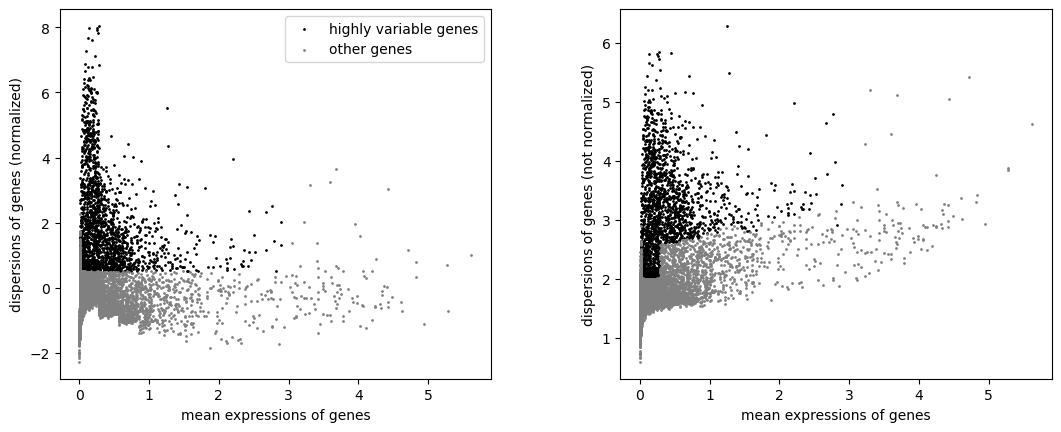

✅ Se seleccionaron 1826 genes altamente variables para la reducción dimensional y Clustering.


In [25]:
# Celda 17: Selección de Genes Altamente Variables (HVGs)
print("🔍 Identificando los genes más informativos (HVGs)...")

# 1. Calcular variabilidad por gen (métoda Seurat)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

# 2. Visualizar la distribución de variabilidad
sc.pl.highly_variable_genes(adata)

# 3. Guardar en metadatos cuántos genes altamente variables se encontraron
num_hvg = adata.var['highly_variable'].sum()
print(f"✅ Se seleccionaron {num_hvg} genes altamente variables para la reducción dimensional y Clustering.")

c:\Users\User\anaconda3\envs\singlecell_env\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


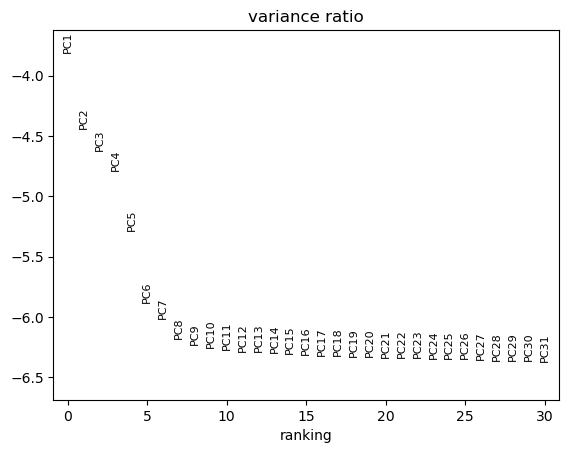

In [26]:
# Celda 18: Selección final de HVGs, Escalado (Z-score) y PCA
import scanpy as sc

# 1. Mantener en la matriz principal únicamente los genes altamente variables
adata = adata[:, adata.var['highly_variable']].copy()

# 2. Escalar los datos a varianza unitaria y media cero (Z-score), limitando valores extremos a 10
sc.pp.scale(adata, max_value=10)

# 3. Calcular Análisis de Componentes Principales (PCA)
sc.tl.pca(adata, svd_solver='arpack')

# 4. Graficar la varianza explicada por cada componente (Elbow Plot)
sc.pl.pca_variance_ratio(adata, log=True)

🕸️ Construyendo grafo de vecinos y calculando UMAP/Clustering...


c:\Users\User\anaconda3\envs\singlecell_env\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


✅ UMAP y Clustering finalizados.


C:\Users\User\AppData\Local\Temp\ipykernel_32524\2603736284.py:13: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


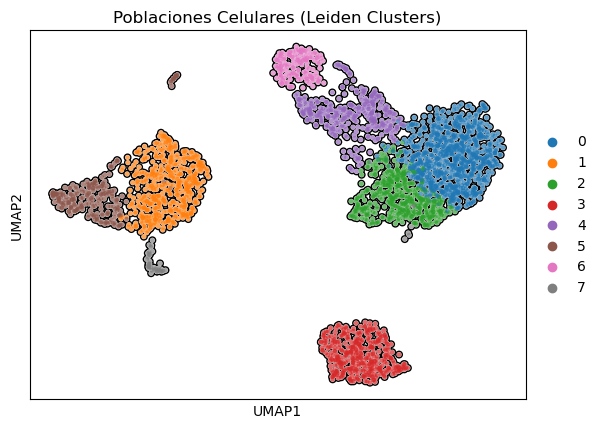

In [27]:
# Celda 19: Grafo de Vecinos, Proyección UMAP y Clustering de Leiden
import scanpy as sc

print("🕸️ Construyendo grafo de vecinos y calculando UMAP/Clustering...")

# 1. Calcular vecinos cercanos usando los primeros 10 PCs
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=10)

# 2. Calcular la proyección bidimensional UMAP
sc.tl.umap(adata)

# 3. Agrupar células mediante el algoritmo de Leiden
sc.tl.leiden(adata, resolution=0.5)

print("✅ UMAP y Clustering finalizados.")

# 4. Graficar el UMAP con los clusters identificados
sc.pl.umap(adata, color=['leiden'], title='Poblaciones Celulares (Leiden Clusters)', add_outline=True)

🧬 Calculando genes marcadores para cada cluster...


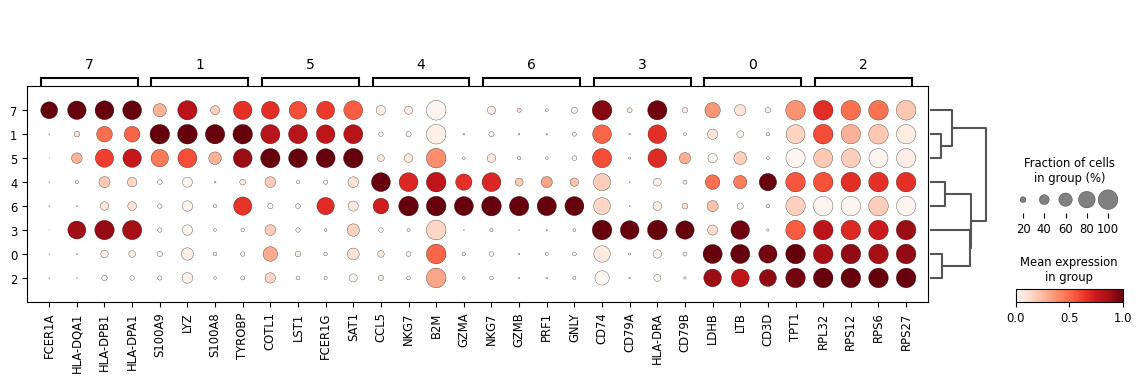

In [28]:
# Celda 20: Análisis de Expresión Diferencial (Rank Genes Groups)
import scanpy as sc

print("🧬 Calculando genes marcadores para cada cluster...")

# 1. Ajustar llamada de Leiden con flavor='igraph' para evitar el FutureWarning
# sc.tl.leiden(adata, resolution=0.5, flavor="igraph", n_iterations=2, directed=False)

# 2. Calcular los genes más expresados diferencialmente en cada cluster (Wilcoxon rank-sum test)
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon')

# 3. Visualizar el Top 5 de genes por cluster en una matriz de puntos
sc.pl.rank_genes_groups_dotplot(adata, n_genes=4, groupby='leiden', standard_scale='var')